# LangChain Chains - A Comprehensive Guide

## What Are Chains?

In LangChain, a **chain** is a sequence of operations where data flows from one component to the next. Chains allow you to:
- Connect prompts, language models, and output parsers together
- Process data through multiple steps sequentially
- Execute multiple operations in parallel
- Make decisions (route) based on data
- Reuse components in different combinations

## Key Components

1. **PromptTemplate**: Creates customizable prompts with variable placeholders
2. **Language Model (LLM)**: Processes text and generates responses
3. **Output Parser**: Transforms model output into structured data
4. **LCEL (LangChain Expression Language)**: The pipe operator `|` chains components together

## Why Use Chains?

- **Modularity**: Each component is reusable and replaceable
- **Simplicity**: Complex workflows become readable with LCEL syntax
- **Traceability**: LangSmith integration allows you to trace and debug chains
- **Flexibility**: Easy to modify, test, and experiment with different combinations

## Simple Chain

### What is a Simple Chain?

A simple chain connects three basic components in sequence:
1. **Prompt Template** → Creates a message based on input variables
2. **Language Model** → Processes the prompt and generates a response
3. **Output Parser** → Converts the model's response into plain text

**Example Flow**: `{topic} → Prompt → Model → Parser → Results`

This is the most fundamental building block of LangChain applications.

#### Step 1: Import Required Libraries

Here we import the necessary components:
- `ChatOpenAI`: Interface to OpenAI's GPT models
- `PromptTemplate`: Used to create reusable prompt templates with variable placeholders
- `StrOutputParser`: Converts model output to a simple string format
- `load_dotenv()`: Loads environment variables (like API keys) from a `.env` file

In [1]:
from click import prompt
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()

True

#### Step 2: Configure LangSmith Tracing

LangSmith helps you debug and monitor your chains:
- `LANGCHAIN_API_KEY`: Your LangSmith API key for authentication
- `LANGCHAIN_TRACING_V2`: Enables tracing to capture all chain operations
- `LANGSMITH_PROJECT`: Organizes traces under a specific project name

In [2]:

import os

os.environ["LANGCHAIN_API_KEY"] = str(os.getenv("LANGCHAIN_API_KEY"))
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGSMITH_PROJECT"]="FinX-Agentic-AI"

#### Step 3: Create a Prompt Template

In this example:
- Template: "Generate 10 interesting facts about {topic}"
- Input: "Gen AI"
- Output: A complete prompt ready to send to the model

In [3]:
# Create individual components
# 1. Prompt Template
message = [{"role": "human", "content": "Generate 5 interesting facts about {topic}"},
           {"role": "system", "content": "You are a helpful assistant that provides interesting facts about various topics."}]
prompt_template = ChatPromptTemplate.from_messages(message)
    

prompt = prompt_template.invoke({'topic':'Capoeira'})
print("Prompt: ", prompt)

Prompt:  messages=[HumanMessage(content='Generate 5 interesting facts about Capoeira', additional_kwargs={}, response_metadata={}), SystemMessage(content='You are a helpful assistant that provides interesting facts about various topics.', additional_kwargs={}, response_metadata={})]


#### Step 4: Initialize a Language Model

`ChatOpenAI()` creates a connection to OpenAI's chat models:
- By default, uses GPT-3.5-turbo (most cost-effective)
- Can specify different models: `ChatOpenAI(model="gpt-4")`
- Returns an `AIMessage` object containing the response

In [4]:
# 2. Language Model
model = ChatOpenAI()
result = model.invoke(prompt)
print("Output: ", result)

Output:  content='1. Capoeira is an Afro-Brazilian martial art that combines elements of dance, acrobatics, and music. It was developed by enslaved Africans in Brazil as a way to practice self-defense and preserve their cultural heritage.\n\n2. Capoeira is unique in that it is played to the rhythm of traditional Brazilian music, specifically the berimbau, a musical bow instrument. The music sets the pace and style of the game, with players engaging in a dialogue of movement and strategy.\n\n3. Capoeira was originally practiced in secret by enslaved Africans in Brazil, disguised as a form of dance to avoid detection by slave owners. Over time, it evolved into a recognized martial art and cultural practice with a global following.\n\n4. Capoeira is characterized by its fluid and rhythmic movements, as well as its emphasis on improvisation and playfulness. Participants often engage in "jogos" or games where they showcase their skills, agility, and creativity in a non-competitive and coope

In [5]:
# 3. Output Parser
parser = StrOutputParser()
parsed_result = parser.invoke(result)

print("Output: ", parsed_result)

Output:  1. Capoeira is an Afro-Brazilian martial art that combines elements of dance, acrobatics, and music. It was developed by enslaved Africans in Brazil as a way to practice self-defense and preserve their cultural heritage.

2. Capoeira is unique in that it is played to the rhythm of traditional Brazilian music, specifically the berimbau, a musical bow instrument. The music sets the pace and style of the game, with players engaging in a dialogue of movement and strategy.

3. Capoeira was originally practiced in secret by enslaved Africans in Brazil, disguised as a form of dance to avoid detection by slave owners. Over time, it evolved into a recognized martial art and cultural practice with a global following.

4. Capoeira is characterized by its fluid and rhythmic movements, as well as its emphasis on improvisation and playfulness. Participants often engage in "jogos" or games where they showcase their skills, agility, and creativity in a non-competitive and cooperative manner.


#### Step 5: Create an Output Parser

`StrOutputParser()` transforms the model output:
- Extracts the text content from the `AIMessage` object
- Returns a simple string instead of a complex object
- This makes the output easier to work with in downstream applications

In [6]:
# Create the combined chain using LangChain Expression Language (LCEL)
chain = prompt_template | model | parser

result = chain.invoke({'topic':'AgenticAI'})
print("Output: ", result)


Output:  1. AgenticAI is an artificial intelligence platform that specializes in automating customer interactions and providing personalized recommendations.
2. AgenticAI utilizes advanced algorithms to analyze customer behavior data and generate insights to improve marketing campaigns and sales strategies.
3. The platform is equipped with natural language processing capabilities, allowing it to understand and respond to customer inquiries in a human-like manner.
4. AgenticAI has been successfully implemented by various companies across industries such as retail, e-commerce, and banking to enhance customer engagement and drive revenue growth.
5. The technology behind AgenticAI is constantly evolving, with ongoing research and development efforts aimed at further improving the platform's capabilities and performance.


#### Step 6: Build the Chain Using LCEL

The pipe operator `|` connects components into a chain:
- `prompt_template | model | parser` means: Output of prompt_template → Input to model → Output of model → Input to parser
- This is much cleaner and more readable than nested function calls
- Data automatically flows from one component to the next
- The final chain accepts the same input as the first component (prompt template)

In [7]:
chain.get_graph().print_ascii()

     +-------------+       
     | PromptInput |       
     +-------------+       
            *              
            *              
            *              
  +--------------------+   
  | ChatPromptTemplate |   
  +--------------------+   
            *              
            *              
            *              
      +------------+       
      | ChatOpenAI |       
      +------------+       
            *              
            *              
            *              
   +-----------------+     
   | StrOutputParser |     
   +-----------------+     
            *              
            *              
            *              
+-----------------------+  
| StrOutputParserOutput |  
+-----------------------+  


#### Step 7: Visualize the Chain Structure

`chain.get_graph().print_ascii()` creates an ASCII diagram showing:
- The flow of data through the chain
- Each component in the pipeline
- How components connect to each other
- Useful for understanding and debugging complex chains

## 2. Sequential Chain

### What is a Sequential Chain?

A sequential chain connects multiple chains where:
- The **output** of one chain becomes the **input** to the next chain
- Multiple processing steps are applied one after another
- Useful for complex workflows (e.g., generate report → summarize → extract key points)

**Example Flow**: `{topic} → Generate Report → Summarize Report → {final_summary}`

Real-world use cases:
- Content generation → Content refinement → Content publishing
- User input → Analysis → Recommendation generation
- Raw data → Processing → Formatting → Output

In [8]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()

True

#### Recreate Basic Components

We initialize the basic components again for this section:
- Model, Parser, and Prompt Templates are the building blocks
- Each section starts fresh for clarity and independence

In [9]:
model = ChatOpenAI()
parser = StrOutputParser()
prompt1 = PromptTemplate(
    template='Generate a detailed report on {topic}',
    input_variables=['topic']
)


#### Define the First Prompt Template

**Step 1** of the sequential chain:
- Takes user input topic (e.g., "India's economic changes in last 5 years")
- Generates a detailed report about that topic
- Output will be used as input for the next step

In [10]:
prompt2 = PromptTemplate(
    template='Generate a 5 pointer summary from the following text \n {text}',
    input_variables=['text']
)

#### Define the Second Prompt Template

**Step 2** of the sequential chain:
- Takes the detailed report (output from Step 1) as input via the `{text}` variable
- Summarizes it into 5 key points
- This demonstrates how outputs flow between prompts in a chain

In [11]:
# sequential chain

seq_chain = prompt1 | model | parser | prompt2 | model | parser

#### Assemble the Sequential Chain

Notice the chain includes TWO complete pipelines connected together:
- `prompt1 | model | parser`: Generates the detailed report
- `prompt2 | model | parser`: Summarizes that report

The key magic: The `{text}` variable in `prompt2` automatically receives the output from the first chain!
This is what makes it "sequential" - each step's output becomes the next step's input.

In [12]:
result = seq_chain.invoke({'topic': "India's economic changes in last 5 years"})

print(result)

1. GDP growth has fluctuated from 8.2% in 2016-17 to 4.0% in 2020-21 due to the pandemic, with a projected growth rate of 9.5% in 2021-22.
2. Inflation rates have varied from 5.0% in 2016 to 2.9% in 2020, rising to around 6.0% in 2021.
3. Unemployment rate peaked at 7.8% in April 2020 but has been gradually decreasing, with challenges in job creation post-pandemic.
4. Foreign Direct Investment (FDI) has increased significantly over the past five years, reaching $81.72 billion in 2020-21 despite pandemic challenges.
5. Reforms such as GST and IBC have been introduced to improve the ease of doing business and attract investments, with efforts to increase exports and reduce trade deficit.


#### Execute the Sequential Chain

Running the chain:
1. Provides only the initial input (`topic: 'India's economic changes in last 5 years'`)
2. The first prompt/model/parser generates a detailed report
3. That output automatically feeds into the second prompt
4. The second model/parser generates a 5-point summary
5. Final output is returned

This entire multi-step process happens with a single `.invoke()` call!

In [13]:
seq_chain.get_graph().print_ascii()

     +-------------+       
     | PromptInput |       
     +-------------+       
            *              
            *              
            *              
    +----------------+     
    | PromptTemplate |     
    +----------------+     
            *              
            *              
            *              
      +------------+       
      | ChatOpenAI |       
      +------------+       
            *              
            *              
            *              
   +-----------------+     
   | StrOutputParser |     
   +-----------------+     
            *              
            *              
            *              
+-----------------------+  
| StrOutputParserOutput |  
+-----------------------+  
            *              
            *              
            *              
    +----------------+     
    | PromptTemplate |     
    +----------------+     
            *              
            *              
            *       

## Parallel Chains

### What is a Parallel Chain?

A parallel chain executes **multiple chains simultaneously** on the same input:
- All chains receive the same input data
- Each chain processes independently
- Results are combined into a structured output (usually a dictionary)
- Useful when you need multiple perspectives or outputs from the same input

**Example Flow**:
```
Input {text}
  ├─→ Notes Chain  ─→ {notes}
  └─→ Quiz Chain   ─→ {quiz}
         ↓
    Merge Results → {final_output}
```

**Benefits**:
- Generate multiple types of content from one input (e.g., summary + quiz + notes)
- More efficient than running chains sequentially
- Combine outputs for richer results

In [14]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser


from dotenv import load_dotenv
load_dotenv()
model = ChatOpenAI(model="gpt-4o-mini")
parser = StrOutputParser()


#### Define Parallel Chain Prompts

Create **two different prompt templates** that will run on the same input:
1. **First prompt**: Generates study notes from text
2. **Second prompt**: Creates quiz questions from text

Both will receive the same input (the same text) and generate different outputs.

In [39]:
prompt1 = PromptTemplate(
    template='Generate short and simple notes from the following text \n {text}',
    input_variables=['text']
)

In [40]:
prompt2 = PromptTemplate(
    template='Generate 5 short question answers from the following text \n {text}',
    input_variables=['text']
)

#### Create Two Independent Chains

Create two complete chains:
- `notes_chain`: prompt1 → model → parser (generates notes)
- `quiz_chain`: prompt2 → model → parser (generates quiz)

Each chain can work independently, but we'll combine them next.

In [41]:
notes_chain = prompt1 | model | parser
quiz_chain = prompt2 | model | parser

#### Execute Chains in Parallel

`RunnableParallel` runs multiple chains simultaneously:
- Dictionary keys ('notes', 'quiz') define output names
- Values are the chains to execute in parallel
- Input is broadcast to all chains
- Output is a dictionary: `{'notes': 'generated notes', 'quiz': 'generated quiz'}`

This is the key to parallel execution!

In [42]:
from langchain_classic.schema.runnable import RunnableParallel
parallel_chain = RunnableParallel(
    {
    'notes': notes_chain,
    'quiz': quiz_chain
    }
)

#### Create a Merge Prompt

After parallel chains produce their outputs, we combine them:
- Takes both `{notes}` and `{quiz}` as inputs
- Creates a prompt that merges both outputs
- Next step will process this merged prompt

In [43]:
prompt3 = PromptTemplate(
    template='Merge the provided notes and quiz into a single document \n notes -> {notes} and quiz -> {quiz}',
    input_variables=['notes', 'quiz']
)

#### Assemble the Complete Parallel + Sequential Chain

The final chain combines:
1. **Parallel execution**: `parallel_chain` (notes & quiz generated simultaneously)
2. **Sequential merge**: `merge_chain` (processes combined outputs)

This is a hybrid chain: parallel processing followed by sequential post-processing!

In [44]:
merge_chain = prompt3 | model | parser

In [45]:
final_chain = parallel_chain | merge_chain

#### Sample Text for Processing

This text about Support Vector Machines (SVMs) will be processed by:
- notes_chain: Extract key learning points
- quiz_chain: Generate 5 question-answer pairs
- merge_chain: Combine both outputs

The same input goes to both chains in parallel, then results are merged.

In [46]:
text = """
Support vector machines (SVMs) are a set of supervised learning methods used for classification, regression and outliers detection.

The advantages of support vector machines are:

Effective in high dimensional spaces.

Still effective in cases where number of dimensions is greater than the number of samples.

Uses a subset of training points in the decision function (called support vectors), so it is also memory efficient.

Versatile: different Kernel functions can be specified for the decision function. Common kernels are provided, but it is also possible to specify custom kernels.

The disadvantages of support vector machines include:

If the number of features is much greater than the number of samples, avoid over-fitting in choosing Kernel functions and regularization term is crucial.

SVMs do not directly provide probability estimates, these are calculated using an expensive five-fold cross-validation (see Scores and probabilities, below).

The support vector machines in scikit-learn support both dense (numpy.ndarray and convertible to that by numpy.asarray) and sparse (any scipy.sparse) sample vectors as input. However, to use an SVM to make predictions for sparse data, it must have been fit on such data. For optimal performance, use C-ordered numpy.ndarray (dense) or scipy.sparse.csr_matrix (sparse) with dtype=float64.
"""

In [47]:
result = final_chain.invoke({'text':text})
print(result)

# Support Vector Machines (SVMs): Notes and Quiz

## Notes on Support Vector Machines (SVMs)

- **Purpose**:  
  Support vector machines are used for classification, regression, and outlier detection in supervised learning.

- **Advantages**:  
  - Effective in high-dimensional spaces.
  - Works well when dimensions exceed the number of samples.
  - Memory efficient by using only a subset of training points (support vectors).
  - Versatile with customizable Kernel functions.

- **Disadvantages**:  
  - Risk of over-fitting when features outnumber samples; careful Kernel and regularization selection needed.
  - Probability estimates require costly five-fold cross-validation.

- **Implementation Notes (scikit-learn)**:  
  - Supports both dense and sparse input formats.
  - For predictions on sparse data, the model must be trained on such data.
  - Optimal data format: C-ordered `numpy.ndarray` (dense) or `scipy.sparse.csr_matrix` (sparse) with `dtype=float64`.

## Quiz

1. **What are su

In [48]:
final_chain.get_graph().print_ascii()

            +---------------------------+            
            | Parallel<notes,quiz>Input |            
            +---------------------------+            
                 **               **                 
              ***                   ***              
            **                         **            
+----------------+                +----------------+ 
| PromptTemplate |                | PromptTemplate | 
+----------------+                +----------------+ 
          *                               *          
          *                               *          
          *                               *          
  +------------+                    +------------+   
  | ChatOpenAI |                    | ChatOpenAI |   
  +------------+                    +------------+   
          *                               *          
          *                               *          
          *                               *          
+-----------------+         

## Conditional Chain

### What is a Conditional Chain?

A conditional chain makes **decisions** and **routes** data to different chains:
- Evaluates input using a classifier/router
- Based on the result, sends data to different processing chains
- Each route handles data differently
- Useful for handling multiple scenarios with different logic

**Example Flow** (Feedback processing):
```
Input: Customer feedback
  ↓
Classifier: Determine sentiment (positive/negative/neutral/escalate)
  ├─→ Positive → Thank you response
  ├─→ Negative → Apologize + solution
  ├─→ Neutral  → Request more details  
  └─→ Escalate → Escalate to human agent
```

**Real-world applications**:
- Customer service automation (route by sentiment)
- Content moderation (different handling for different violation types)
- Smart routing (redirect users based on intent)

#### Import Conditional Chain Components

New imports for conditional chains:
- `ChatPromptTemplate`: Advanced prompt template with message roles
- `RunnableBranch`: Routes data based on conditions (like if/else)
- `PydanticOutputParser`: Parses output into structured Python objects
- `BaseModel, Field, Literal`: Used to define data schemas

In [25]:

from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.runnables import  RunnableBranch, RunnableParallel
from langchain_core.output_parsers import PydanticOutputParser, StrOutputParser
from pydantic import BaseModel, Field
from typing import Literal
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

True

In [26]:
# Create a ChatOpenAI model
model = ChatOpenAI(model="gpt-4o")
parser = StrOutputParser() 

#### Define the Feedback Schema

`Pydantic` models define structured data formats:
- `sentiment`: The field we'll classify feedback into
- `Literal`: Only allows specific values (no typos or invalid values)
- `Field`: Provides description for AI model (helps it understand what to extract)

The model will analyze feedback and return: `{'sentiment': 'positive'}` (or other values)

In [27]:
class Feedback(BaseModel):
    sentiment: Literal['positive', 'negative', 'neutral', 'escalate'] = Field(description='Give the sentiment of the feedback')

In [28]:
feedback_parser = PydanticOutputParser(pydantic_object=Feedback)

#### Create Classification Prompt

`ChatPromptTemplate.from_messages()` allows multi-role prompts:
- **system**: Instructions to guide the model's behavior
- **human**: The actual question/prompt with placeholders

`.partial(format_instructions=...)`: Injects formatting instructions so the model returns structured output matching our Pydantic schema

In [ ]:
# Define the feedback classification template
# FIX: The `partial_variables` argument is not supported in `from_messages`.
# We use the `.partial()` method on the template object instead.
classification_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant."),
        ("human",
         "Classify the sentiment of this feedback as positive, negative, neutral, or escalate: {feedback}\n {format_instructions}"),
    ]
).partial(format_instructions=feedback_parser.get_format_instructions())

In [49]:
# Create the classification chain
classification_chain = classification_prompt | model | feedback_parser
result= classification_chain.invoke({"feedback": "The product is okay, but I expected more features for the price."})
print(result)

sentiment='neutral'


#### Define Response Prompts for Each Sentiment

Each sentiment category gets its own **specialized response prompt**:
- **Positive feedback**: Thank the customer and encourage more feedback
- **Negative feedback**: Apologize and offer solutions
- **Neutral feedback**: Request more details for better understanding
- **Escalate**: Pass to human agent

Later, these will be used in a `RunnableBranch` to route based on classified sentiment.

In [31]:
# Define prompt templates for different feedback types
positive_feedback_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant."),
        ("human",
         "Generate a thank you note for this positive feedback: {feedback}."),
    ]
)


In [32]:
negative_feedback_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant."),
        ("human",
         "Generate an appropriate response addressing this negative feedback: {feedback}."),
    ]
)

In [33]:
neutral_feedback_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant."),
        (
            "human",
            "Generate a request for more details for this neutral feedback: {feedback}.",
        ),
    ]
)

In [34]:
escalate_feedback_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant."),
        (
            "human",
            "Generate a message to escalate this feedback to a human agent: {feedback}.",
        ),
    ]
)

#### Create Conditional Routing Logic

`RunnableBranch` implements if/else-like logic:
- **First tuple**: `(condition, chain)` - if sentiment == 'positive', run positive_feedback_prompt chain
- **Second tuple**: if sentiment == 'negative', run negative_feedback_prompt chain
- **Third tuple**: if sentiment == 'neutral', run neutral_feedback_prompt chain
- **Last item**: Default chain if no conditions match (escalate)

The lambda functions extract and check the sentiment from the classification result.
This is the "decision router" of the conditional chain!

In [35]:
# Define the runnable branches for handling feedback
# FIX: The lambda functions now correctly check the `.sentiment` attribute of the Pydantic object
branches = RunnableBranch(
    (
        lambda x: x.sentiment == 'positive',
        positive_feedback_prompt | model | parser  # Positive feedback chain
    ),
    (
        lambda x: x.sentiment == 'negative',
        negative_feedback_prompt | model | parser  # Negative feedback chain
    ),
    (
        lambda x: x.sentiment == 'neutral',
        neutral_feedback_prompt | model | parser  # Neutral feedback chain
    ),
    escalate_feedback_prompt | model | parser
)

#### Combine Classification and Routing

The complete conditional chain has two steps:
1. **Classification**: Analyzes feedback and returns structured sentiment
2. **Routing**: Sends to appropriate response chain based on sentiment

`classification_chain | branches` means:
- First classify the sentiment
- Then route to the appropriate response chain

In [36]:
# Combine classification and response generation into one chain
chain = classification_chain | branches

In [37]:
# Run the chain with an example review
# Good review - "The product is excellent. I really enjoyed using it and found it very helpful."
# Bad review - "The product is terrible. It broke after just one use and the quality is very poor."
# Neutral review - "The product is okay. It works as expected but nothing exceptional."
# Default - "I'm not sure about the product yet. Can you tell me more about its features and benefits?"

result = chain.invoke(
    {
        "feedback": "The product is terrible. It broke after just one use and the quality is very poor."
    }
)

print(result)

I'm sorry to hear that you had a negative experience. Your feedback is important to us, and we would like to address any concerns you might have. Could you please provide more details about the issue? We are committed to resolving this matter and improving our services. Thank you for bringing this to our attention.


#### Execute the Conditional Chain

This demonstrates the complete flow:
1. Input: Customer feedback ("The product is terrible...")
2. Classification: Model determines this is "negative"
3. Routing: RunnableBranch routes to negative_feedback_prompt chain
4. Response: Generates an appropriate apology/solution response

Try different feedback types to see routing in action:
- Positive feedback → Thank you response
- Negative feedback → Apology + solution
- Neutral feedback → Request for details  
- Default → Escalation message

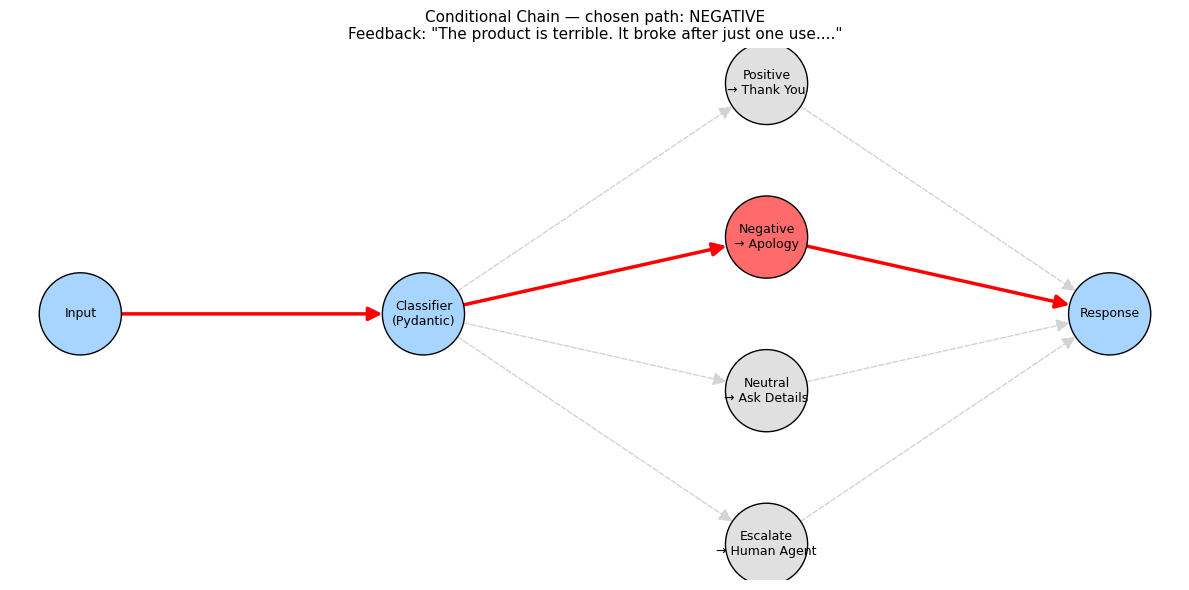

In [53]:
#chain.get_graph().print_ascii()
import matplotlib.pyplot as plt
import networkx as nx

def visualize_conditional_chain(feedback_text, chain, classification_chain):
    # Run classification to find which branch was chosen
    result = classification_chain.invoke({"feedback": feedback_text})
    chosen = result.sentiment

    G = nx.DiGraph()
    sentiments = {
        'positive': 'Positive\n→ Thank You',
        'negative': 'Negative\n→ Apology',
        'neutral':  'Neutral\n→ Ask Details',
        'escalate': 'Escalate\n→ Human Agent',
    }

    # Nodes
    G.add_node('Input')
    G.add_node('Classifier\n(Pydantic)')
    for key, label in sentiments.items():
        G.add_node(label)
    G.add_node('Response')

    # Edges
    G.add_edge('Input', 'Classifier\n(Pydantic)')
    for key, label in sentiments.items():
        G.add_edge('Classifier\n(Pydantic)', label)
        G.add_edge(label, 'Response')

    # Layered layout
    pos = {
        'Input': (0, 2),
        'Classifier\n(Pydantic)': (1, 2),
        sentiments['positive']: (2, 3.5),
        sentiments['negative']: (2, 2.5),
        sentiments['neutral']:  (2, 1.5),
        sentiments['escalate']: (2, 0.5),
        'Response': (3, 2),
    }

    # Color: chosen path red, others gray
    chosen_label = sentiments[chosen]
    node_colors = []
    for n in G.nodes():
        if n in ('Input', 'Classifier\n(Pydantic)', 'Response'):
            node_colors.append('#a8d5ff')
        elif n == chosen_label:
            node_colors.append('#ff6b6b')
        else:
            node_colors.append('#e0e0e0')

    edge_colors, edge_widths, edge_styles = [], [], []
    for u, v in G.edges():
        on_path = (
            (u == 'Input' and v == 'Classifier\n(Pydantic)') or
            (u == 'Classifier\n(Pydantic)' and v == chosen_label) or
            (u == chosen_label and v == 'Response')
        )
        edge_colors.append('red' if on_path else 'lightgray')
        edge_widths.append(2.5 if on_path else 1)
        edge_styles.append('solid' if on_path else 'dashed')

    plt.figure(figsize=(12, 6))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3500, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=9)
    for (u, v), color, width, style in zip(G.edges(), edge_colors, edge_widths, edge_styles):
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)],
                               edge_color=color, width=width, style=style,
                               arrows=True, arrowsize=20,
                               node_size=3500)
    plt.title(f'Conditional Chain — chosen path: {chosen.upper()}\nFeedback: "{feedback_text[:60]}..."',
              fontsize=11)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Try it with different feedback
visualize_conditional_chain(
    "The product is terrible. It broke after just one use.",
    chain,
    classification_chain
)


## Summary: Chain Types and When to Use Them

### Chain Type Comparison

| Chain Type | Use Case | Example |
|-----------|----------|---------|
| **Simple Chain** | Basic prompt → model → parse | Answering a question |
| **Sequential** | Multi-step workflows | Generate report → summarize → extract |
| **Parallel** | Multiple outputs from same input | Generate notes AND quiz from text |
| **Conditional** | Different logic based on input | Route by sentiment/category |

### Key Takeaways

1. **LCEL Syntax** (`|`): Makes chains readable and composable
2. **Components**: Prompts, Models, Parsers are building blocks
3. **Flexibility**: Combine chains in countless ways
4. **Debugging**: Use `.get_graph().print_ascii()` to visualize flow
5. **LangSmith**: Trace and debug chains in production

### Next Steps

- Experiment: Modify prompts and see how outputs change
- Combine: Create more complex chains by mixing types
- Scale: Add error handling and retry logic for production
- Monitor: Use LangSmith to track performance and costs